In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap

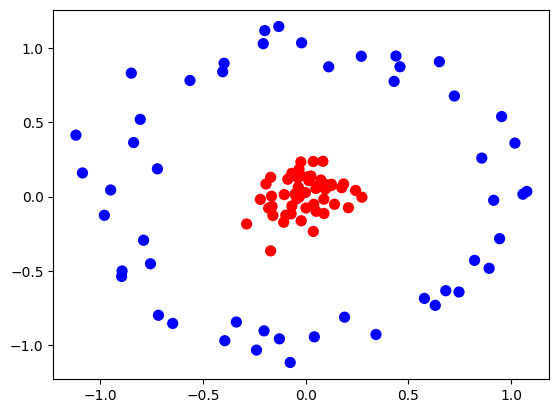

In [7]:
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='bwr')

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)

In [9]:
classifier = SVC(kernel="linear")
classifier.fit(X_train, y_train.ravel())
y_pred = classifier.predict(X_test)

In [10]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.4

In [11]:
zero_one_colourmap = ListedColormap(('blue', 'red'))
def plot_decision_boundary(X, y, clf):
    X_set, y_set = X, y
    X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, 
                                 stop = X_set[:, 0].max() + 1, 
                                 step = 0.01),
                       np.arange(start = X_set[:, 1].min() - 1, 
                                 stop = X_set[:, 1].max() + 1, 
                                 step = 0.01))
  
    plt.contourf(X1, X2, clf.predict(np.array([X1.ravel(), 
                                             X2.ravel()]).T).reshape(X1.shape),
               alpha = 0.75, 
               cmap = zero_one_colourmap)
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = (zero_one_colourmap)(i), label = j)
    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    return plt.show()

/tmp/ipykernel_22662/3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


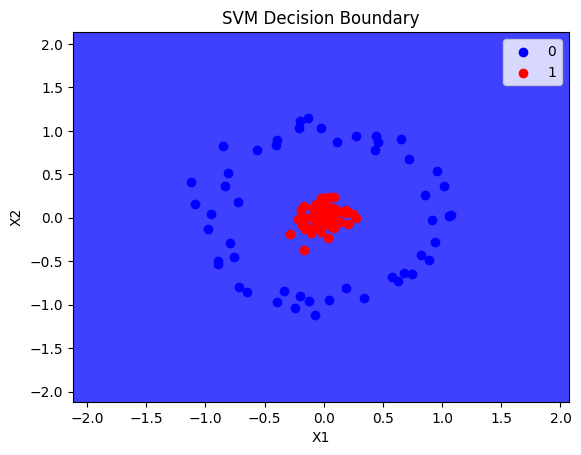

In [12]:
plot_decision_boundary(X, y, classifier)

In [13]:
def plot_3d_plot(X, y):
    r = np.exp(-(X ** 2).sum(1))
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=100, cmap='bwr')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')
    return ax

<Axes3D: xlabel='X1', ylabel='X2', zlabel='y'>

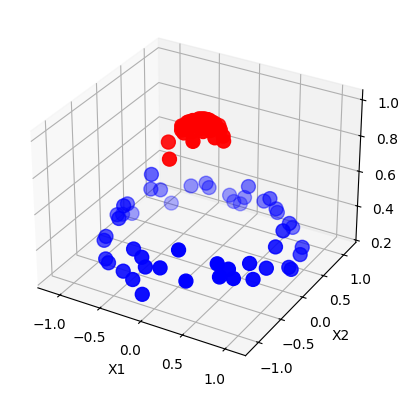

In [14]:
plot_3d_plot(X,y)

In [15]:
rbf_classifier = SVC(kernel="rbf")
rbf_classifier.fit(X_train, y_train)
y_pred = rbf_classifier.predict(X_test)

In [16]:
accuracy_score(y_test, y_pred)

1.0

/tmp/ipykernel_22662/3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


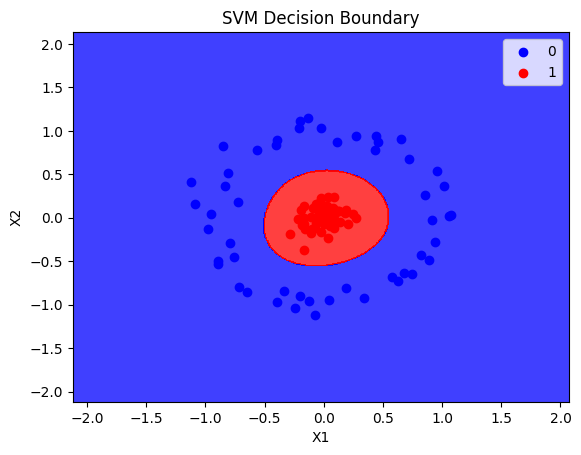

In [17]:
plot_decision_boundary(X, y, rbf_classifier)

In [18]:
poly_classifier = SVC(kernel="poly",degree=2)
poly_classifier.fit(X_train, y_train)
y_pred = poly_classifier.predict(X_test)

In [19]:
accuracy_score(y_test, y_pred)

1.0

/tmp/ipykernel_22662/3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


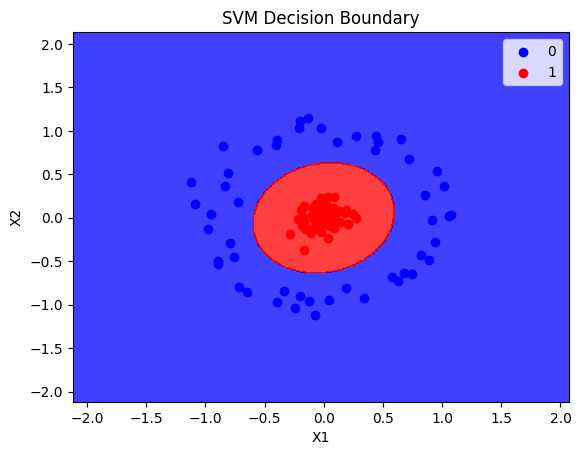

In [20]:
plot_decision_boundary(X, y, poly_classifier)

In [21]:
X

array([[-0.10432163,  0.01338415],
       [ 0.0099327 ,  0.13344099],
       [-0.33746708, -0.84318849],
       [ 0.11219123,  0.87250107],
       [ 0.89340869, -0.48222191],
       [-1.08672851,  0.15906278],
       [ 0.2710411 ,  0.94369451],
       [-0.03236043,  0.18400593],
       [ 0.12488852,  0.07401903],
       [ 0.02547966,  0.13837116],
       [-0.02327482,  0.23320356],
       [ 0.17560691,  0.06025065],
       [-0.03081537, -0.00143282],
       [-1.11875192,  0.41314153],
       [-0.84895992,  0.82985735],
       [-0.13070972,  1.14371178],
       [ 0.03733504, -0.23425033],
       [-0.06718329, -0.06265844],
       [-0.22044146, -0.01869168],
       [ 0.27382413, -0.00411436],
       [-0.40410239,  0.83937254],
       [-0.28770769, -0.18377066],
       [ 0.0368961 ,  0.23604711],
       [ 0.20819167, -0.07455848],
       [-0.71672244, -0.79768844],
       [-0.05192204,  0.01670067],
       [-0.02392133,  0.14057485],
       [-0.16611355,  0.00229825],
       [-0.02151146,

In [22]:
np.exp(-(X**2)).sum(1)

array([1.98899688, 1.98225245, 1.38353053, 1.45457043, 1.24266755,
       1.28199452, 1.33959639, 1.96566194, 1.97906003, 1.98038655,
       1.94652689, 1.96600929, 1.99904881, 1.12913141, 0.98864263,
       1.25339961, 1.94521222, 1.99157819, 1.95221806, 1.92774543,
       1.34367024, 1.88734983, 1.9444452 , 1.9520386 , 1.1275266 ,
       1.99702886, 1.97986062, 1.97277824, 1.97350338, 1.98823543,
       1.96922099, 1.22851359, 1.23263659, 1.33320458, 1.95468307,
       1.3418784 , 1.98213318, 1.37953191, 1.40941659, 1.32649892,
       1.41442934, 1.95880984, 1.24762854, 1.98830389, 1.94084727,
       1.84679472, 1.24906829, 1.995735  , 1.3719585 , 1.30567301,
       1.2337518 , 1.23550688, 1.93817552, 1.2575273 , 1.99798198,
       1.31250552, 1.19758512, 1.27174935, 1.99416532, 1.97919474,
       1.27661769, 1.22497277, 1.45402897, 1.98370454, 1.29791531,
       1.9876871 , 1.98170142, 1.99925409, 1.95937635, 1.1408488 ,
       1.99458943, 1.97783794, 1.40388837, 1.99173405, 1.95617

In [23]:
X_new=np.exp(-(X**2))

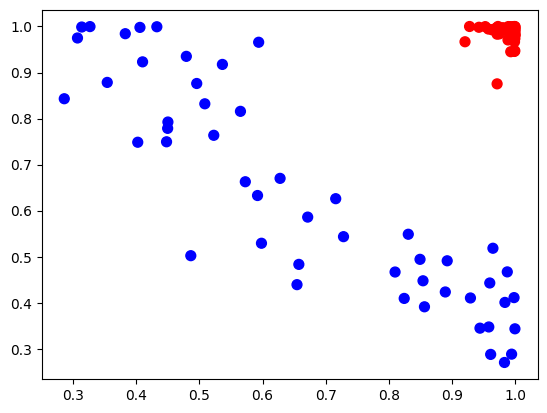

In [24]:
plt.scatter(X_new[:, 0], X_new[:, 1], c=y, s=50, cmap='bwr')